# Multi-Season Analysis of Disciplinary Behaviour in Serie A

In notebook 03, we tested a single season (2025/26) and found that Juventus's yellow card rate per foul was statistically different from the rest of the league. But before concluding anything about Juventus specifically, we need to ask a more fundamental question.

**Is finding a statistical outlier in a single season unusual at all?**

With 20 teams and a test threshold of 5%, we expect roughly one team to appear "significant" by chance alone in any given season. If that is all we found, the 2025/26 result is unremarkable. If, on the other hand, the same teams appear as outliers season after season, that is a much stronger signal - and it points toward structural causes worth investigating.

This notebook does not start from Juventus. It starts from all teams across all 15 available Serie A seasons and lets the data reveal whether outlier status is random rotation or a persistent pattern.

In [40]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

with open("../data/processed/team_matches.pkl", "rb") as f:
    team_matches = pickle.load(f)

# Filter to Serie A, all seasons
sa = team_matches[team_matches['league'] == 'Serie_A'].copy()
sa['ycards_per_foul'] = sa['yellow_cards'] / sa['fouls_committed']

print(f"Serie A: {sa['season'].nunique()} seasons, {sa['team'].nunique()} unique teams")
print(f"Seasons: {sorted(sa['season'].unique())}")

Serie A: 15 seasons, 40 unique teams
Seasons: ['1112', '1213', '1314', '1415', '1516', '1617', '1718', '1819', '1920', '2021', '2122', '2223', '2324', '2425', '2526']


**A note on 2025/26**: this season is incomplete (30 of 38 matchdays at time of writing). We include it throughout but flag results from it with extra caution - a smaller sample means wider confidence intervals and less reliable p-values.

**A note on promotions and relegations**: Serie A is not a fixed pool of 20 teams. Each season the bottom three clubs are relegated to Serie B and replaced by three promoted sides. This has two consequences worth keeping in mind.

First, the reference rate $p_0$ is computed from the teams actually present in that season. This is the correct approach - we always compare a team to its real contemporaries - but it means $p_0$ itself shifts slightly from year to year, partly because the mix of teams changes and not only because referee behaviour changes.

Second, newly promoted sides often play differently from established top-flight clubs: more physical, less technically polished, sometimes with different relationships with referees built up over years in the division. A team appearing as an outlier in its first season back in Serie A may simply be adjusting to top-flight refereeing standards rather than exhibiting a persistent structural trait. We flag this when interpreting single-season results in Section 4.

## Section 2 - The landscape: crude rates across all teams and seasons

Before running any test, we want to see the raw picture. For every team-season pair we compute the crude rate: total yellow cards divided by total fouls committed across all matches that season. This is the same metric defined in notebook 03.

We show two heatmaps, one below the other:
- **First**: absolute crude rate - intuitive and directly interpretable
- **Second**: deviation from the season mean - how much each team differs from the average   in that particular season, which makes relative outliers easier to spot across years

Grey cells indicate the team was not in Serie A that season (relegated or not yet promoted).

In [41]:
# Aggregate to team-season level: sum fouls and yellow cards
season_team = (
    sa.groupby(['season', 'team'])
    .agg(
        fouls = ('fouls_committed', 'sum'),
        ycards = ('yellow_cards', 'sum'),
        matches = ('fouls_committed', 'count')
    )
    .reset_index()
)
season_team['crude_rate'] = season_team['ycards'] / season_team['fouls']

# Season mean crude rate (across all teams present that season)
season_mean = season_team.groupby('season')['crude_rate'].mean().rename('season_mean')
season_team = season_team.join(season_mean, on='season')
season_team['deviation'] = season_team['crude_rate'] - season_team['season_mean']

season_team.head()

,season,team,fouls,ycards,matches,crude_rate,season_mean,deviation
0,1112,Atalanta,592.0,96.0,38,0.162162,0.142666,0.019496
1,1112,Bologna,638.0,96.0,38,0.150470,0.142666,0.007804
2,1112,Cagliari,613.0,78.0,38,0.127243,0.142666,-0.015423
3,1112,Catania,587.0,74.0,38,0.126065,0.142666,-0.016602
4,1112,Cesena,622.0,92.0,38,0.147910,0.142666,0.005244


In [42]:
seasons = sorted(sa['season'].unique())
teams   = sorted(sa['team'].unique())

# Readable season labels: '1112' -> '2011-12'
def fmt_season(s):
    return f"20{s[:2]}-{s[2:]}"

season_labels = {s: fmt_season(s) for s in seasons}
readable_seasons = [season_labels[s] for s in seasons]

# Pivot tables
pivot_rate = season_team.pivot(index='team', columns='season', values='crude_rate')
pivot_dev  = season_team.pivot(index='team', columns='season', values='deviation')

pivot_rate = pivot_rate.reindex(index=teams, columns=seasons).rename(columns=season_labels)
pivot_dev  = pivot_dev.reindex(index=teams, columns=seasons).rename(columns=season_labels)

def grey_missing(ax, pivot, teams, seasons):
    for i, team in enumerate(teams):
        for j, season in enumerate(seasons):
            if pd.isna(pivot.loc[team, season]):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#cccccc', lw=0))


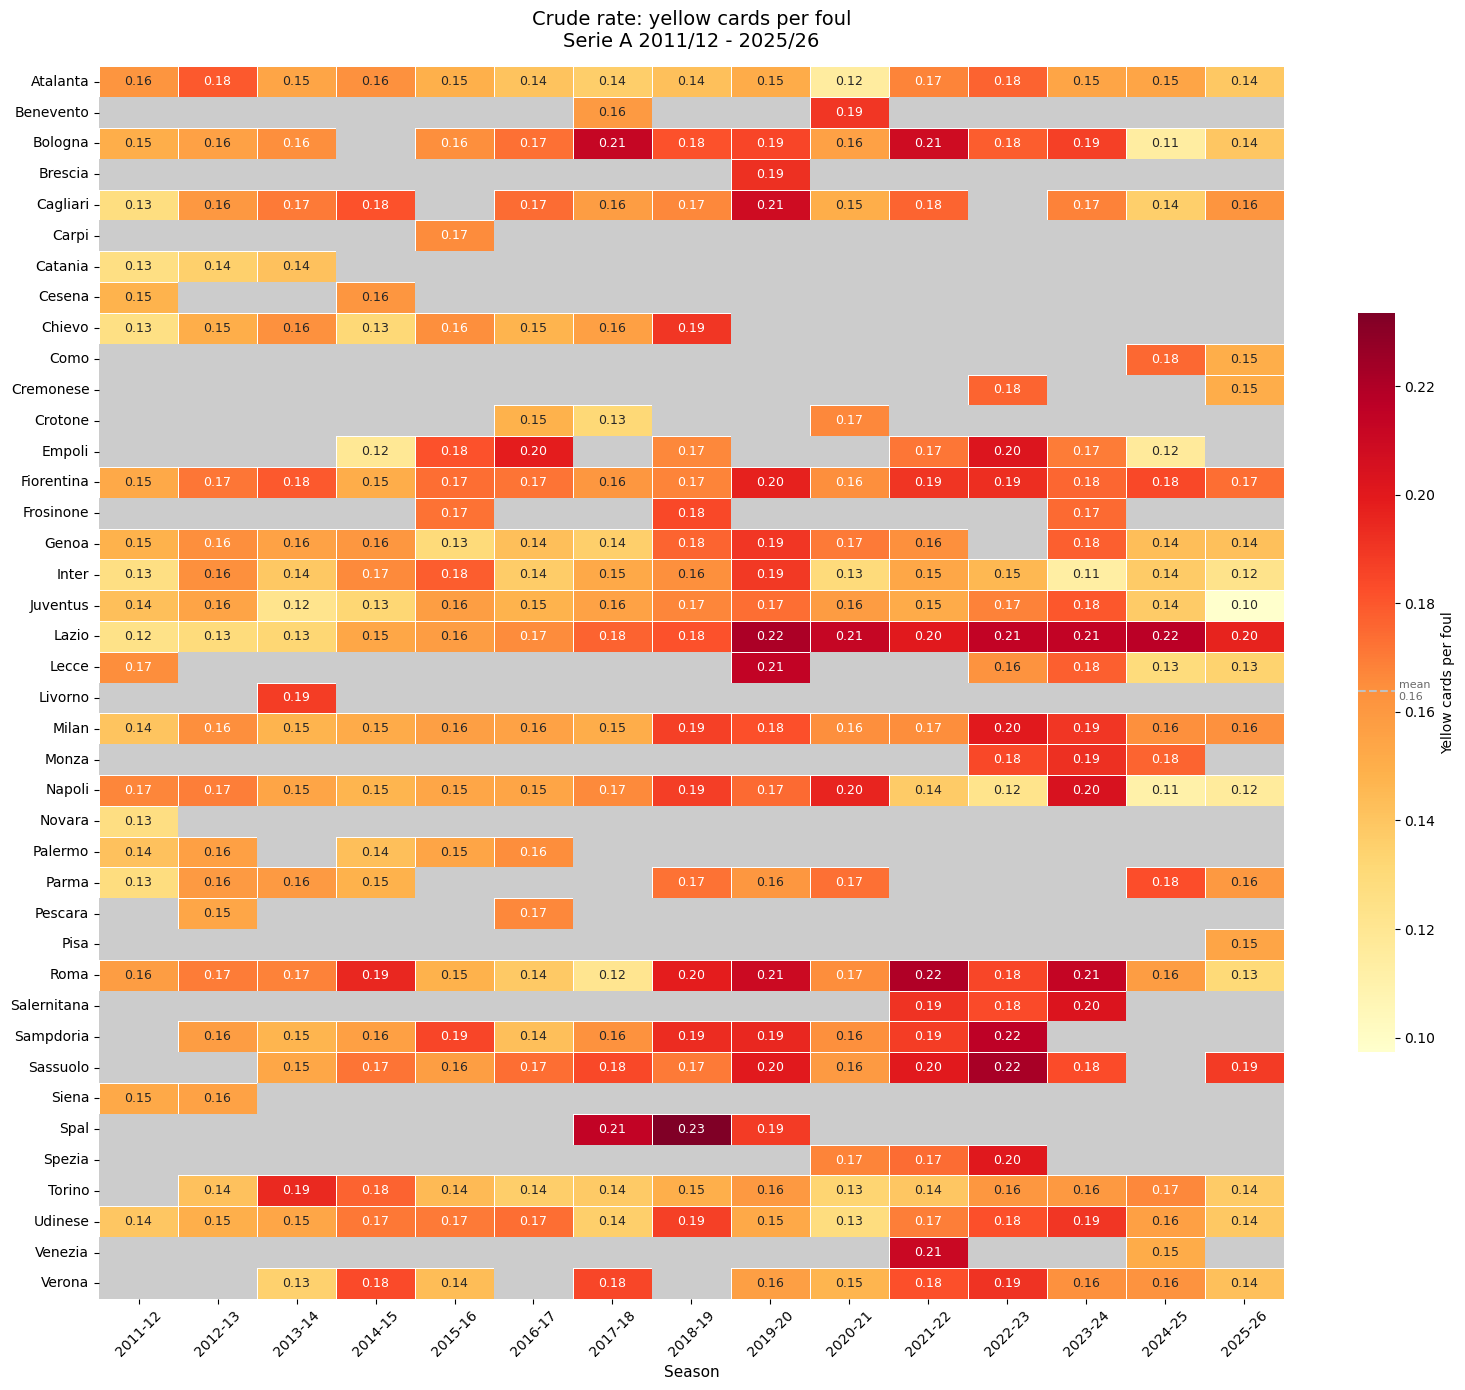

In [43]:
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    pivot_rate,
    ax=ax,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Yellow cards per foul', 'shrink': 0.6},
    mask=pivot_rate.isna()
)
grey_missing(ax, pivot_rate, teams, readable_seasons)

# Mark the overall mean on the colorbar
overall_mean_rate = season_team['crude_rate'].mean()
cbar = ax.collections[0].colorbar
cbar.ax.axhline(y=overall_mean_rate, color='silver', linestyle='--', linewidth=1.5)
cbar.ax.text(1.1, overall_mean_rate, f'mean\n{overall_mean_rate:.2f}',
             va='center', ha='left', fontsize=8, color='dimgrey',
             transform=cbar.ax.get_yaxis_transform())

ax.set_title('Crude rate: yellow cards per foul\nSerie A 2011/12 - 2025/26', fontsize=14, pad=14)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

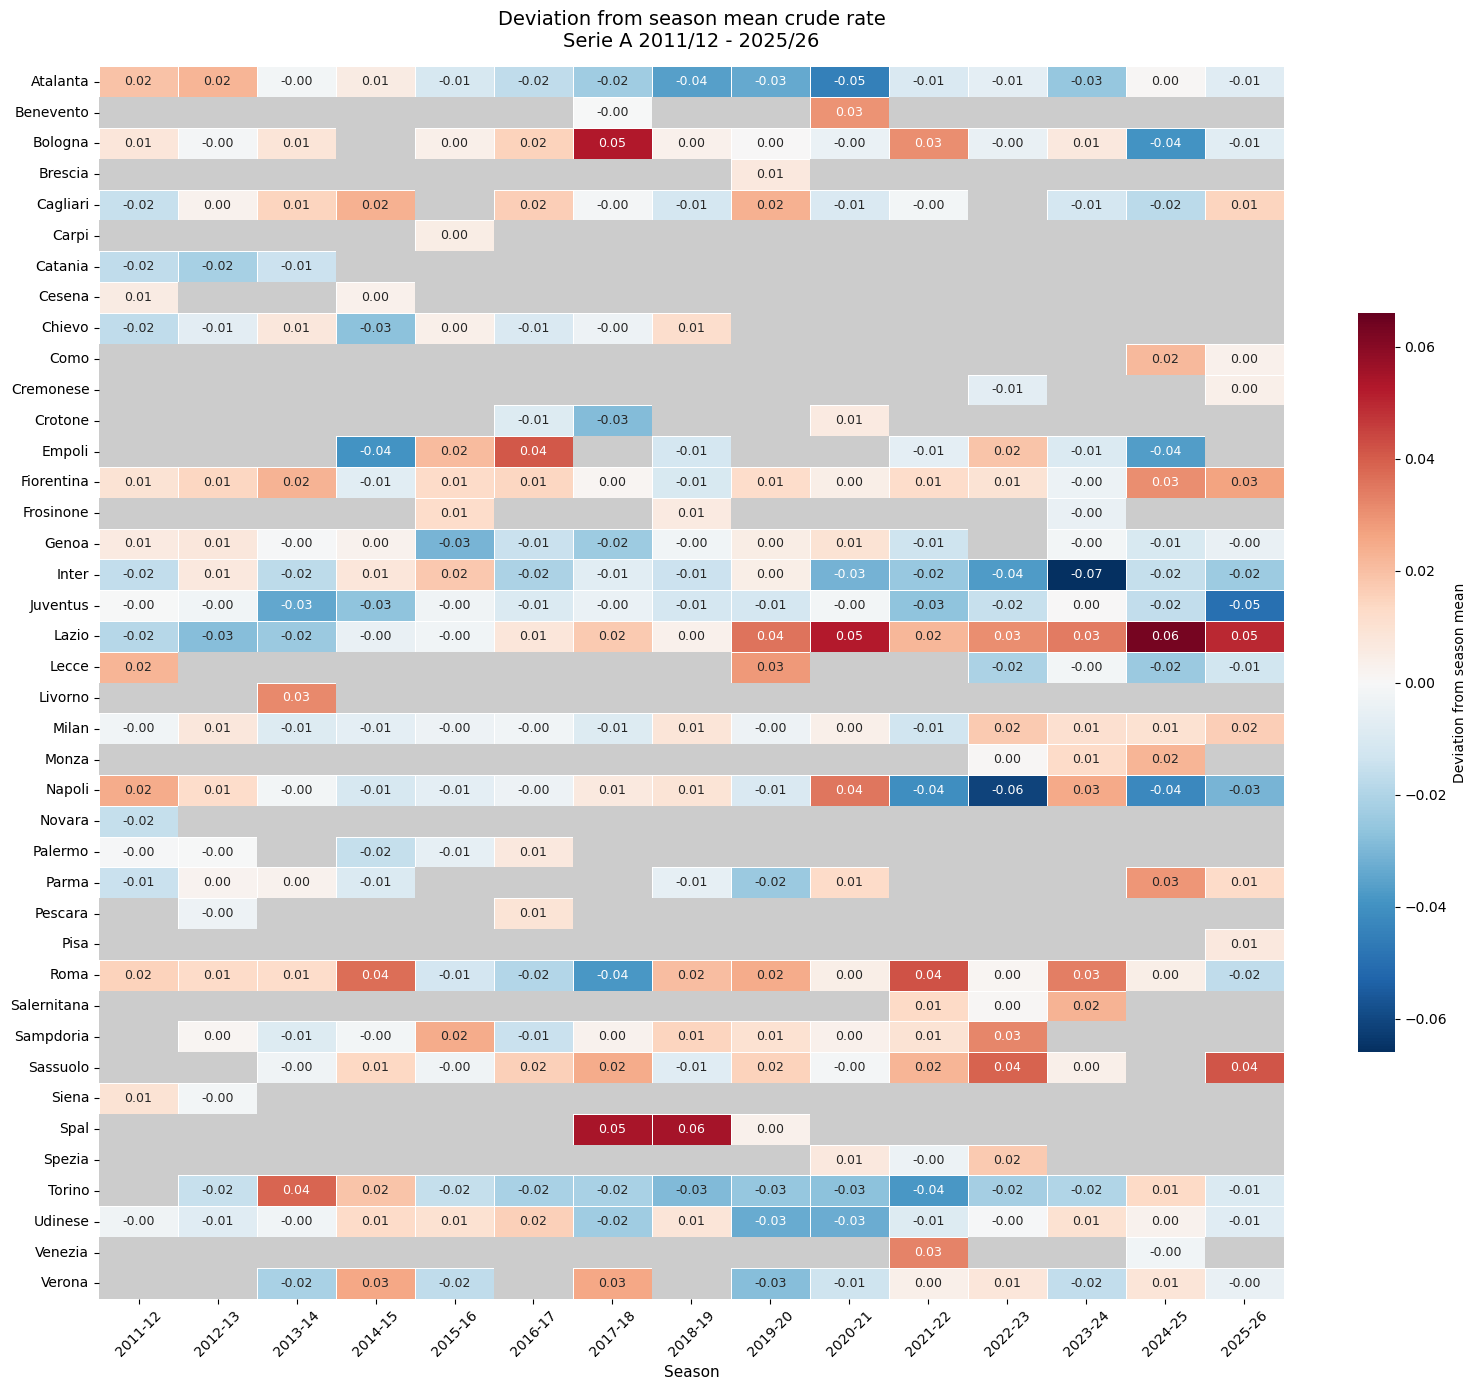

In [44]:
fig, ax = plt.subplots(figsize=(16, 14))

vmax = pivot_dev.abs().max().max()
sns.heatmap(
    pivot_dev,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Deviation from season mean', 'shrink': 0.6},
    mask=pivot_dev.isna()
)
grey_missing(ax, pivot_dev, teams, readable_seasons)

ax.set_title('Deviation from season mean crude rate\nSerie A 2011/12 - 2025/26', fontsize=14, pad=14)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

The first heatmap gives an immediate sense of the overall level: most team-seasons cluster between 0.12 and 0.18. The second strips out year-to-year variation in the league baseline and shows only relative position within each season - making it easier to spot teams that consistently sit above or below the pack regardless of which year it is.

Grey cells are seasons where the team was not in Serie A.

### The same picture, read differently: fouls per yellow card

The crude rate (yellow cards per foul) is the right metric for the statistical tests ahead, but it can feel abstract: a value of 0.15 does not immediately tell you much. The inverse - **fouls per yellow card** - is more tangible. It answers the question: "on average, how many fouls did it take before a yellow card was shown?"

A value of 7 means a team needed 7 fouls per card; a value of 5 means cards came more frequently. Lower is stricter - fewer fouls were tolerated before a card was produced.

The two metrics carry identical information (one is simply 1/other), so they will show the same relative pattern. The inversion just makes the numbers easier to read at a glance.

In [45]:
season_team['fouls_per_card'] = season_team['fouls'] / season_team['ycards']

season_mean_inv = season_team.groupby('season')['fouls_per_card'].mean().rename('season_mean_inv')
season_team = season_team.join(season_mean_inv, on='season')
season_team['deviation_inv'] = season_team['fouls_per_card'] - season_team['season_mean_inv']

pivot_inv  = season_team.pivot(index='team', columns='season', values='fouls_per_card')
pivot_dinv = season_team.pivot(index='team', columns='season', values='deviation_inv')

pivot_inv  = pivot_inv.reindex(index=teams, columns=seasons).rename(columns=season_labels)
pivot_dinv = pivot_dinv.reindex(index=teams, columns=seasons).rename(columns=season_labels)

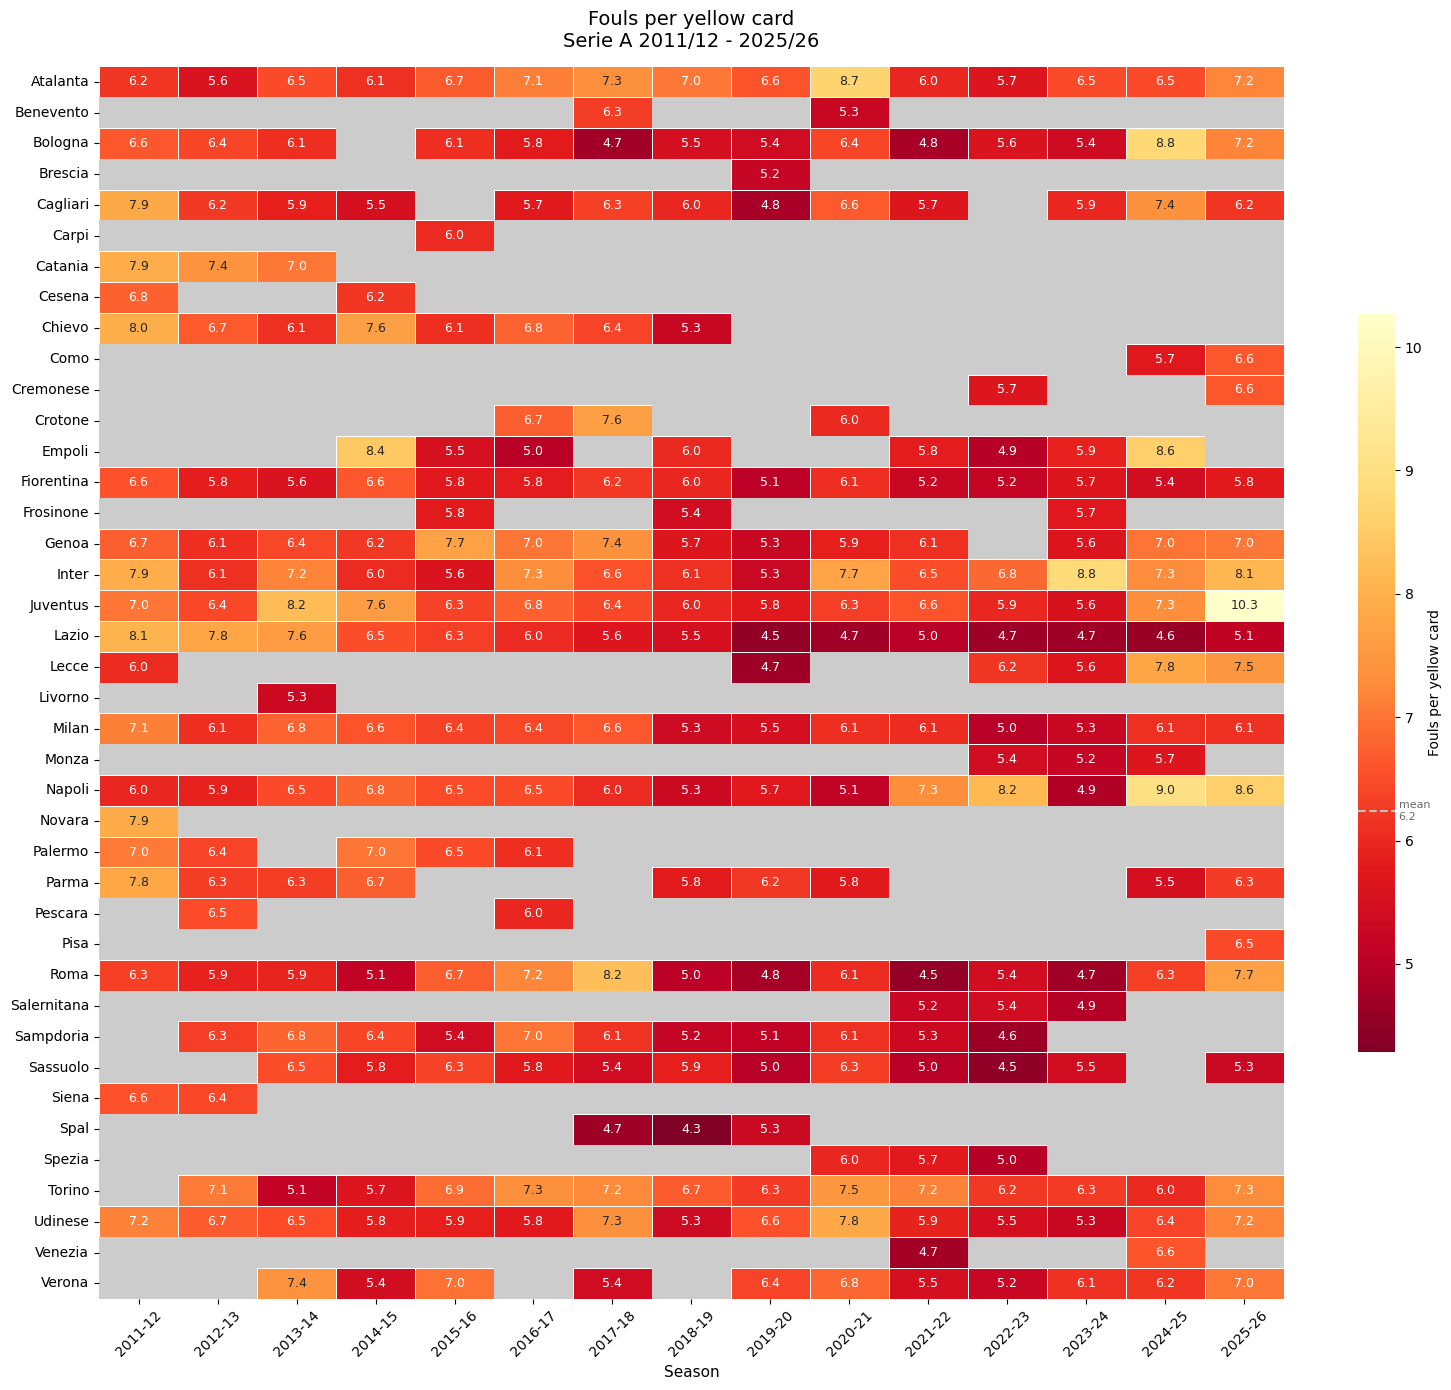

In [46]:
fig, ax = plt.subplots(figsize=(16, 14))

sns.heatmap(
    pivot_inv,
    ax=ax,
    cmap='YlOrRd_r',
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Fouls per yellow card', 'shrink': 0.6},
    mask=pivot_inv.isna()
)
grey_missing(ax, pivot_inv, teams, readable_seasons)

# Mark the overall mean on the colorbar
overall_mean_inv = season_team['fouls_per_card'].mean()
cbar = ax.collections[0].colorbar
cbar.ax.axhline(y=overall_mean_inv, color='silver', linestyle='--', linewidth=1.5)
cbar.ax.text(1.1, overall_mean_inv, f'mean\n{overall_mean_inv:.1f}',
             va='center', ha='left', fontsize=8, color='dimgrey',
             transform=cbar.ax.get_yaxis_transform())

ax.set_title('Fouls per yellow card\nSerie A 2011/12 - 2025/26', fontsize=14, pad=14)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

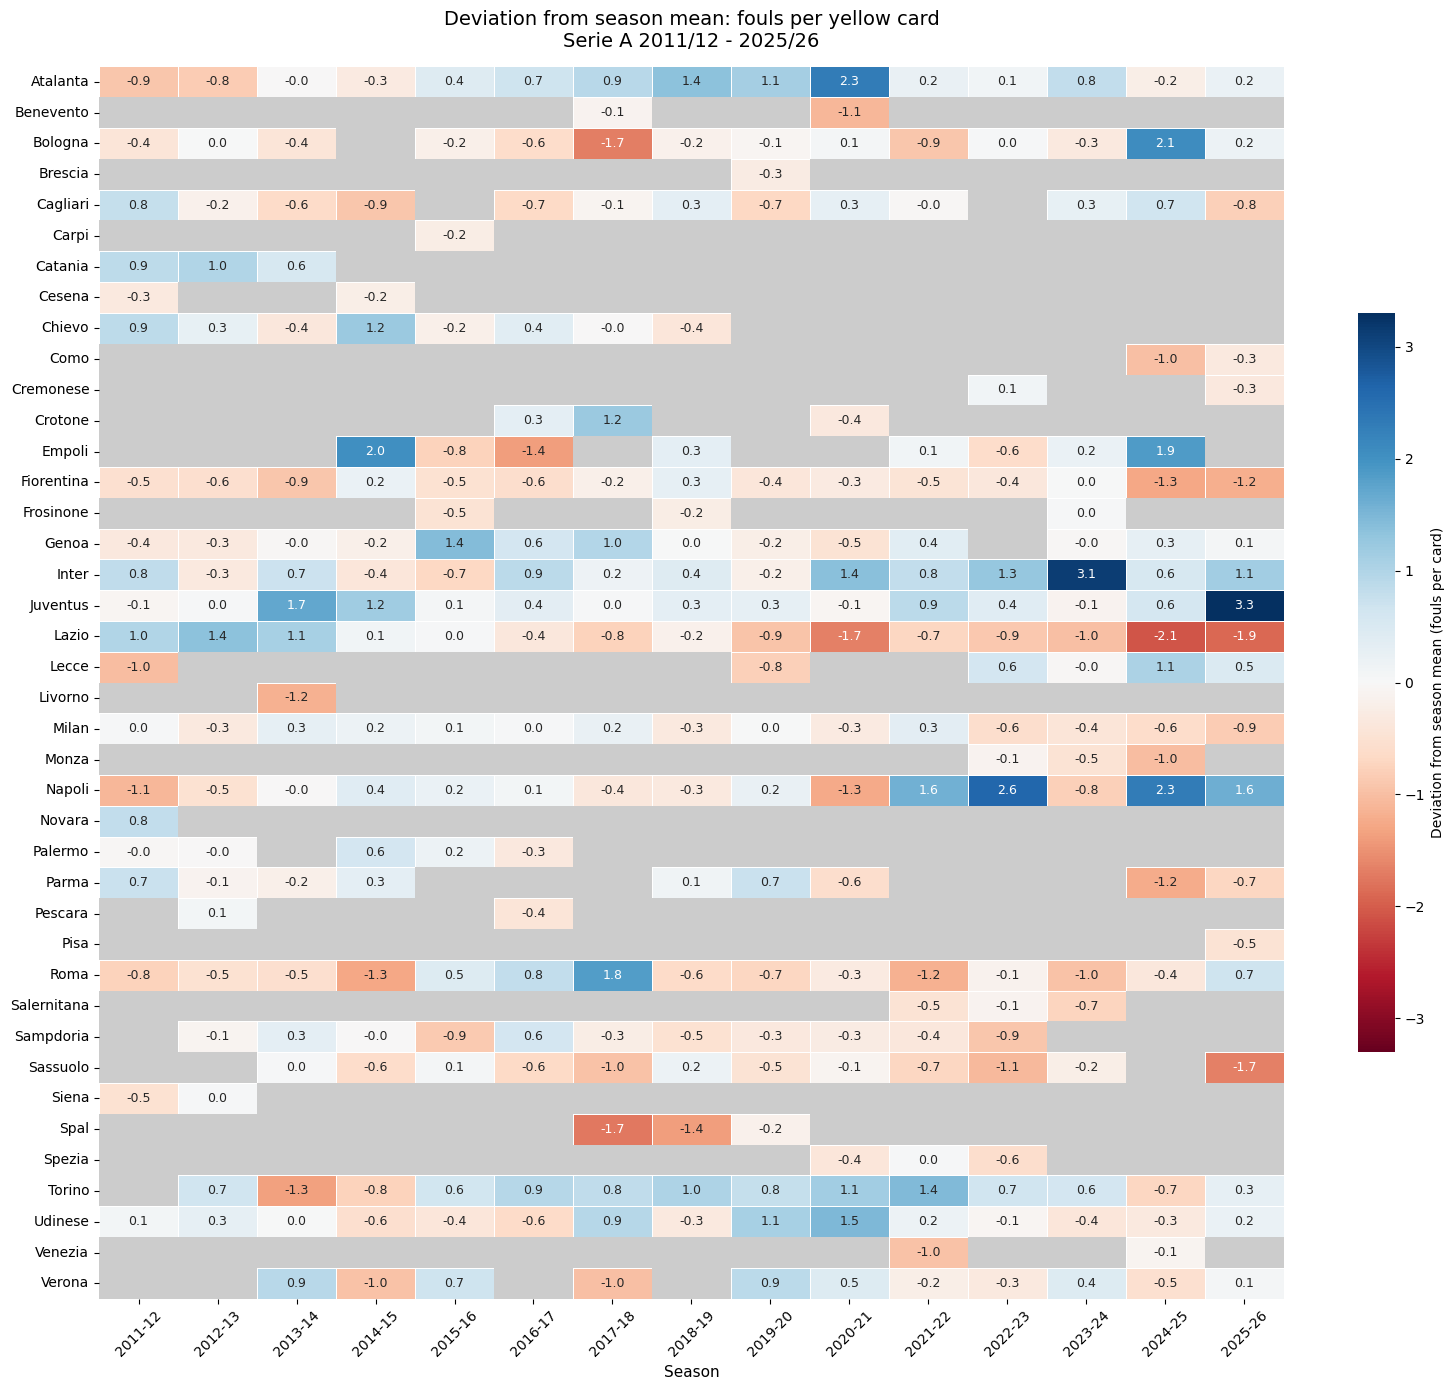

In [47]:
fig, ax = plt.subplots(figsize=(16, 14))

vmax_inv = pivot_dinv.abs().max().max()
sns.heatmap(
    pivot_dinv,
    ax=ax,
    cmap='RdBu',
    center=0,
    vmin=-vmax_inv,
    vmax=vmax_inv,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Deviation from season mean (fouls per card)', 'shrink': 0.6},
    mask=pivot_dinv.isna()
)
grey_missing(ax, pivot_dinv, teams, readable_seasons)

ax.set_title('Deviation from season mean: fouls per yellow card\nSerie A 2011/12 - 2025/26', fontsize=14, pad=14)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

Note the colour scale is reversed: darker red now means *fewer* fouls per card, i.e. the team was carded more strictly. A team at the bottom of the fouls-per-card scale is the same team at the top of the yellow-cards-per-foul scale - the same outlier, just expressed in units that are easier to explain to a non-technical reader.

## Section 3 - How many outliers per season?

The heatmaps give a visual impression, but we need a formal test to distinguish real outliers from visual noise. We now apply the z-test to every team in every season.

For each (team, season) pair:
- $\hat{p}$ = crude rate of the team that season
- $p_0$ = crude rate of all other teams combined that season (the reference, computed excluding the team under test)
- $n$ = total fouls committed by the team that season
- $z = (\hat{p} - p_0) \, / \, \sqrt{p_0(1-p_0)/n}$, two-tailed

We flag a result as significant at $\alpha = 0.05$.

**Why only the z-test here, and not the full pipeline from notebook 03?**

In notebook 03 we built a careful pipeline: z-test, exact binomial to validate the normal approximation, bootstrap, and Mann-Whitney. That level of rigour was appropriate because we were examining a single team in depth. Here we are running 300 tests (20 teams across 15 seasons) in a screening sweep, and a lighter tool is the right choice for this stage.

The justification for the normal approximation holds throughout: with $n$ typically between 400 and 650 fouls per team-season, the CLT conditions ($np_0 > 10$ and $n(1-p_0) > 10$) are comfortably satisfied and the exact binomial would give essentially identical results.

Think of this as a funnel: the z-test identifies which teams are worth a closer look; the full pipeline from notebook 03 will be applied to the persistent outliers that emerge from Section 4.

**The key question**: how many significant teams do we find per season? With 20 teams and $\alpha = 0.05$, we expect about 1 significant result per season by chance alone - even if there is no real effect anywhere. If we consistently find 3 or 4, something structural is going on.

In [48]:
results = []

for season in seasons:
    season_df = sa[sa['season'] == season]

    for team in season_df['team'].unique():
        team_df = season_df[season_df['team'] == team]
        rest_df = season_df[season_df['team'] != team]

        n = int(team_df['fouls_committed'].sum())
        k = int(team_df['yellow_cards'].sum())
        p_hat = k / n
        p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()

        se = np.sqrt(p0 * (1 - p0) / n)
        z  = (p_hat - p0) / se
        p_value = 2 * stats.norm.cdf(-abs(z))

        results.append({
            'season':  season,
            'team':    team,
            'n':       n,
            'k':       k,
            'p_hat':   p_hat,
            'p0':      p0,
            'z':       z,
            'p_value': p_value,
            'significant': p_value < 0.05
        })

results_df = pd.DataFrame(results)
print(f"Total tests run: {len(results_df)}")
print(f"Significant results (p < 0.05): {results_df['significant'].sum()}")
print(f"Expected by chance alone: {len(results_df) * 0.05:.1f}")

Total tests run: 300
Significant results (p < 0.05): 39
Expected by chance alone: 15.0


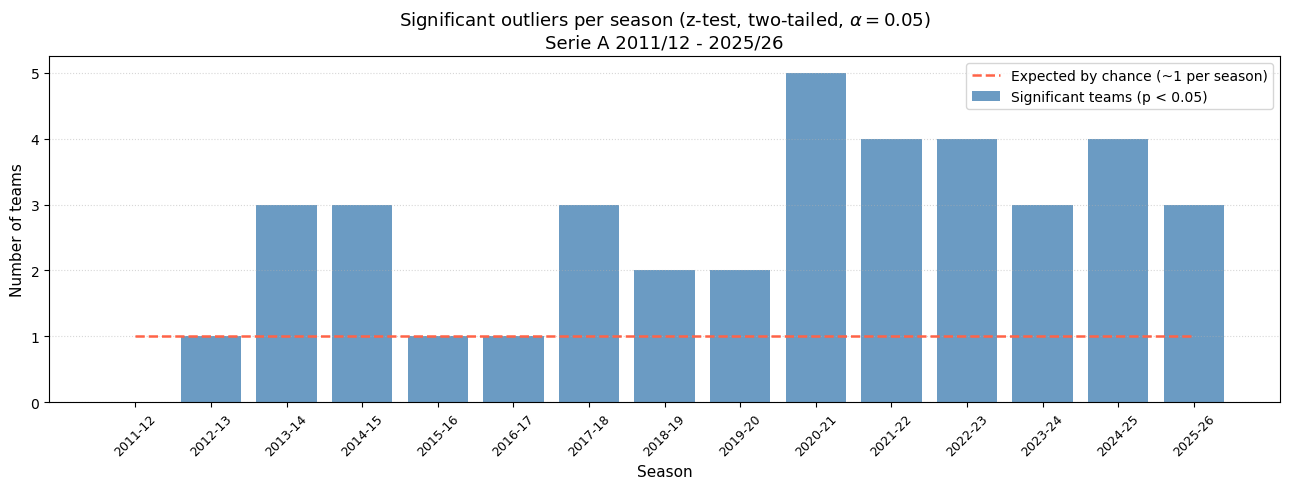

In [49]:
sig_per_season = (
    results_df.groupby('season')['significant']
    .sum()
    .reset_index()
    .rename(columns={'significant': 'n_significant'})
)
sig_per_season['n_teams'] = (
    results_df.groupby('season')['team'].nunique().values
)
sig_per_season['expected'] = sig_per_season['n_teams'] * 0.05
sig_per_season['season_label'] = sig_per_season['season'].map(season_labels)

fig, ax = plt.subplots(figsize=(13, 5))

bars = ax.bar(
    sig_per_season['season_label'],
    sig_per_season['n_significant'],
    color='steelblue', alpha=0.8, label='Significant teams (p < 0.05)'
)

# Expected-by-chance line
ax.plot(
    sig_per_season['season_label'],
    sig_per_season['expected'],
    color='tomato', linestyle='--', linewidth=1.8,
    label='Expected by chance (~1 per season)'
)

ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('Number of teams', fontsize=11)
ax.set_title('Significant outliers per season (z-test, two-tailed, $\\alpha=0.05$)\nSerie A 2011/12 - 2025/26', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

The dashed red line marks the number of significant results we would expect by chance alone at $\alpha = 0.05$ (roughly 1 per season with 20 teams). Bars consistently above this line suggest that finding outliers is not a statistical artefact - there is real structure in the data. Bars at or below the line would mean our 2025/26 finding is entirely unremarkable.

**A note on 2011-12**: the absence of a bar is not a data gap. That season was genuinely homogeneous - crude rates ranged from 0.124 to 0.167 across all 20 teams and even the closest team (Lecce, $p = 0.08$) did not reach significance. It is the exception that proves the rule: when no structural effect is present, the test correctly returns nothing.

We will look at *who* those outliers are in Section 4.

## Section 4 - Who are the outliers?

We now know that finding multiple outliers per season is the norm rather than the exception. The next question is whether the same teams appear repeatedly - or whether outlier status rotates across different clubs each year.

We look at this from two angles:

- **How many seasons** was each team significant? A team appearing once could be chance; a team appearing in 8 out of 15 seasons is telling a different story.
- **When** did they appear? Consecutive seasons suggest a persistent structural trait; scattered appearances are harder to interpret.

We also distinguish **direction**: a team can be a significant outlier because it receives *more* cards per foul than the league average (referees are stricter with them) or *fewer* (referees are more lenient). These are different effects and should not be collapsed together.

**A word on multiple comparisons**: across 300 tests at $\alpha = 0.05$, we expect roughly 15 false positives by chance alone. We found 39 significant results. That still leaves around 24 results that are unlikely to be noise - but it means we should be cautious about teams with only 1 or 2 significant seasons, and focus on those with a consistent pattern.

In [50]:
sig_counts = (
    results_df[results_df['significant']]
    .groupby('team')
    .agg(
        n_significant = ('significant', 'sum'),
        n_above = ('z', lambda x: (x > 0).sum()),   # more cards than average
        n_below = ('z', lambda x: (x < 0).sum())    # fewer cards than average
    )
    .reset_index()
    .sort_values('n_significant', ascending=False)
)

print("Teams with at least one significant season:")
print(sig_counts.to_string(index=False))

Teams with at least one significant season:
     team  n_significant  n_above  n_below
    Lazio              6        5        1
   Napoli              4        1        3
     Roma              4        3        1
 Atalanta              3        0        3
   Empoli              3        1        2
   Torino              2        1        1
 Juventus              2        0        2
 Sassuolo              2        2        0
    Inter              2        0        2
  Bologna              2        1        1
     Spal              2        2        0
Benevento              1        1        0
   Chievo              1        0        1
    Genoa              1        0        1
  Livorno              1        1        0
Sampdoria              1        1        0
  Udinese              1        0        1
  Venezia              1        1        0


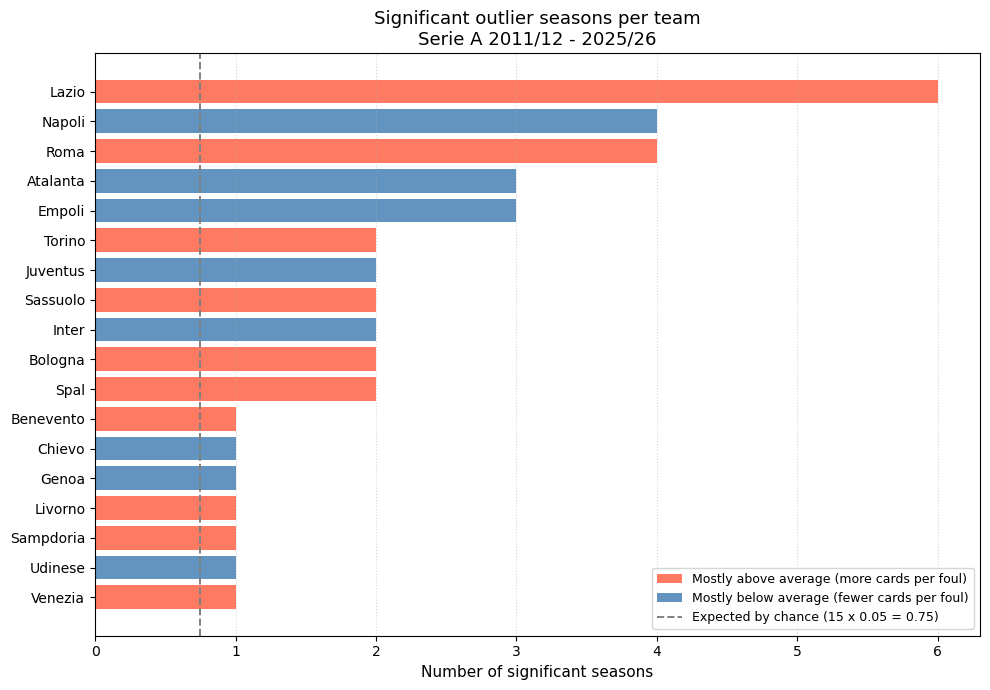

In [51]:
fig, ax = plt.subplots(figsize=(10, 7))

colours = ['tomato' if a >= b else 'steelblue'
           for a, b in zip(sig_counts['n_above'], sig_counts['n_below'])]

ax.barh(sig_counts['team'], sig_counts['n_significant'],
        color=colours, alpha=0.85)

ax.axvline(x=15 * 0.05, color='grey', linestyle='--', linewidth=1.4,
           label='Expected by chance (15 seasons x 0.05)')
ax.set_xlabel('Number of significant seasons', fontsize=11)
ax.set_title('Significant outlier seasons per team\nSerie A 2011/12 - 2025/26', fontsize=13)
ax.invert_yaxis()
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle=':', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tomato',    alpha=0.85, label='Mostly above average (more cards per foul)'),
    Patch(facecolor='steelblue', alpha=0.85, label='Mostly below average (fewer cards per foul)'),
]
ax.legend(handles=legend_elements + [
    plt.Line2D([0], [0], color='grey', linestyle='--', linewidth=1.4,
               label='Expected by chance (15 x 0.05 = 0.75)')
], fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

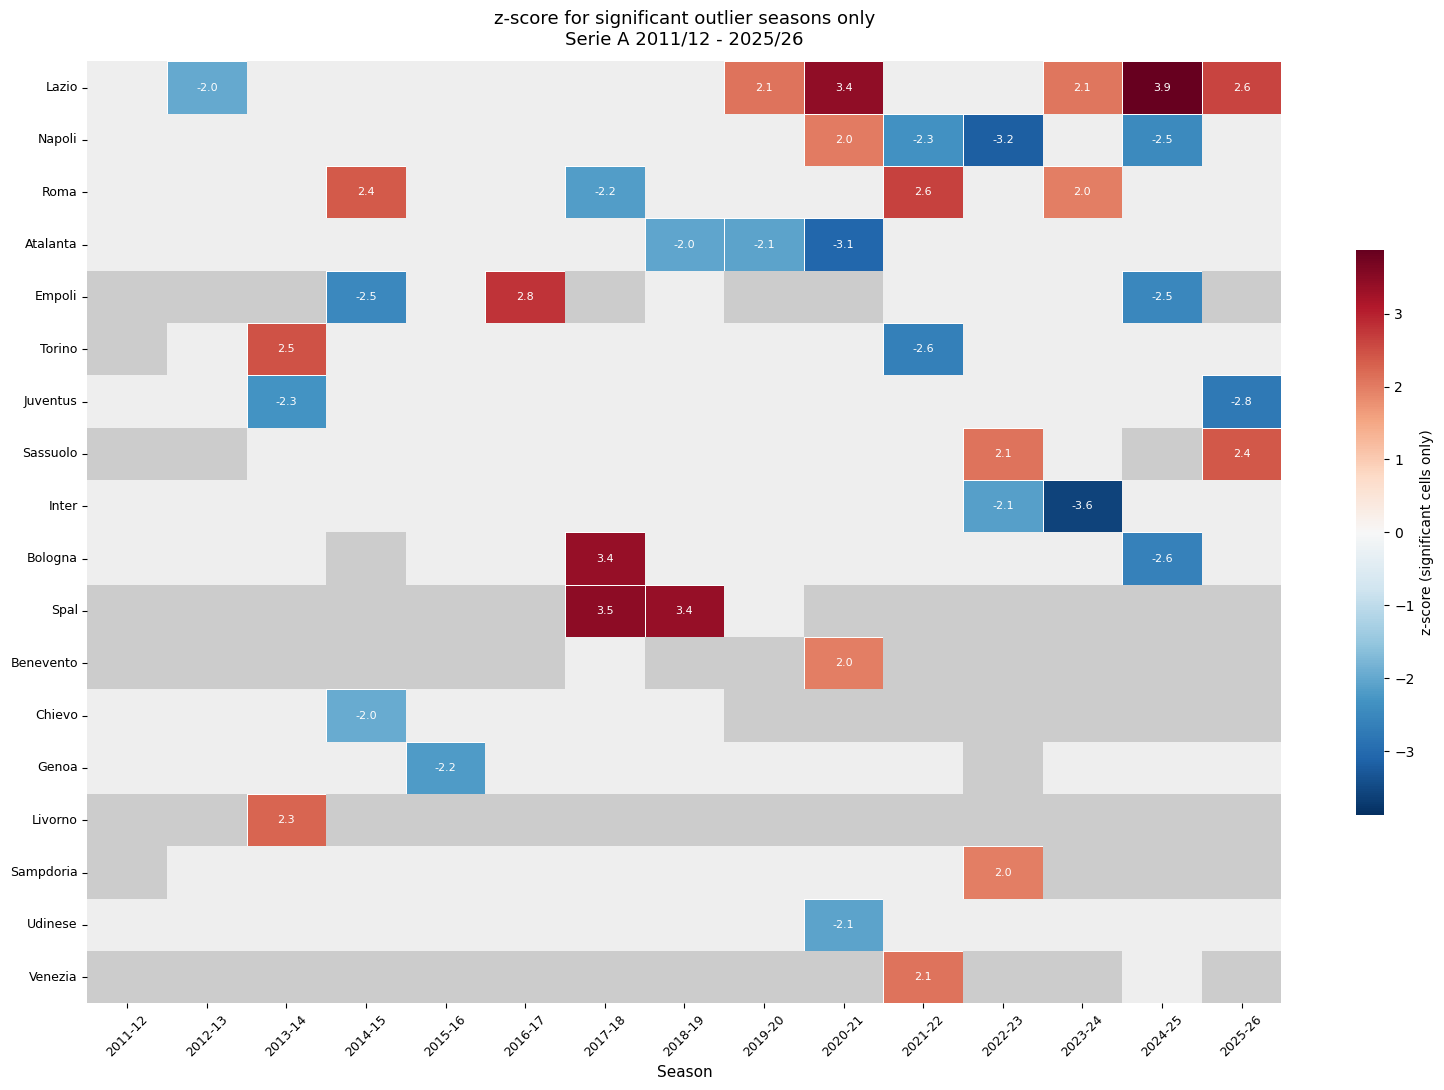

In [52]:
# Only teams with at least one significant season
teams_with_sig = sig_counts['team'].tolist()

pivot_z = results_df.pivot(index='team', columns='season', values='z')
pivot_z = pivot_z.reindex(index=teams_with_sig, columns=seasons)
pivot_z.columns = [season_labels[s] for s in seasons]

# Mask non-significant cells
pivot_sig = results_df.pivot(index='team', columns='season', values='significant')
pivot_sig = pivot_sig.reindex(index=teams_with_sig, columns=seasons)
pivot_sig.columns = [season_labels[s] for s in seasons]

mask_not_sig = ~pivot_sig.fillna(False).astype(bool)

fig, ax = plt.subplots(figsize=(16, max(6, len(teams_with_sig) * 0.5 + 2)))

vmax_z = pivot_z.abs().max().max()
sns.heatmap(
    pivot_z,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax_z,
    vmax=vmax_z,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.1f',
    annot_kws={'size': 8},
    cbar_kws={'label': 'z-score (significant cells only)', 'shrink': 0.6},
    mask=mask_not_sig | pivot_z.isna()
)

# Grey out non-significant and missing cells
for i, team in enumerate(teams_with_sig):
    for j, season in enumerate(readable_seasons):
        if pd.isna(pivot_z.loc[team, season]) or not pivot_sig.loc[team, season]:
            color = '#cccccc' if pd.isna(pivot_z.loc[team, season]) else '#eeeeee'
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color=color, lw=0))

ax.set_title('z-score for significant outlier seasons only\nSerie A 2011/12 - 2025/26', fontsize=13, pad=12)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

The heatmap shows only teams with at least one significant season, and only colours the cells where the result was significant - non-significant seasons are shown in light grey, seasons where the team was not in Serie A in darker grey.

Red cells indicate the team received *more* yellow cards per foul than the rest of the league that season; blue cells indicate *fewer*. The intensity reflects how far the z-score is from zero.

What to look for: teams with several red or blue cells in consecutive seasons - those are the structurally persistent outliers that warrant the deeper analysis in Section 5.

### What the data tells us

The results are more nuanced - and more interesting - than the single-season analysis suggested.

**Lazio is the real persistent outlier.** With 6 significant seasons, no other team comes close. But the pattern is not uniform across the full 15 years: one early blue season (2012-13, fewer cards than average) is followed by a long quiet period, then a consistent run of red from 2020-21 onwards. Something changed around 2020. This kind of structural break - a team's relationship with referees shifting over time - is exactly what notebook 05 should investigate.

**Napoli and Roma share the same count but point in opposite directions.** Napoli appears blue (fewer cards per foul than the league average); Roma appears mostly red (more cards). Collapsing them into a single "outlier" category would obscure two completely different phenomena. Direction matters as much as significance.

**Atalanta is the counterintuitive result.** Three significant blue seasons for a team widely known as one of the most aggressive, physically demanding sides in the league. If anything, a naive expectation would put Atalanta in red. The fact that they appear in blue raises a genuine question: does their high foul rate actually *reduce* the probability of a card per foul, perhaps because their fouls are committed earlier in moves, away from goal, and are less likely to be sanctioned? Or is something else at play? A question for notebook 05.

**The Juventus finding from notebook 03, in context.** Across 15 seasons Juventus is significant in only 2 - both blue, both recently. The 2025/26 result we examined in depth is statistically real for that season, but it is not a persistent structural trait of the club. This is precisely why the multi-season approach matters: it prevents us from over-interpreting a single-season finding. Juventus is not the story here.

**Teams appearing once** are mostly clubs that spent only one or two seasons in Serie A during this window - Benevento, Chievo, Livorno, Venezia, Spal. Consistent with the note on promoted sides: a newly promoted team adjusting to top-flight refereeing is a plausible explanation for a single outlier season that never repeats.

**Candidates for deeper analysis.** The primary statistical candidates are Lazio, Napoli, Roma, and Atalanta - persistent signals, clear direction, enough seasons to support deeper analysis. We also include Inter, Juventus, and Milan. Inter and Juventus each have two significant seasons and are among the most followed clubs in Italy. Milan is the most instructive case of all: zero significant seasons across 15 years. For one of the most iconic clubs in the country, referees show no measurable bias in either direction. The absence of a signal is a result too - and it makes the rest of the analysis more credible.

**A note on managers.** Several of the patterns above have a natural alternative explanation: if the disciplinary profile of a club shifts when the manager changes, the effect belongs to the coach rather than the institution. The Lazio break around 2020 is the clearest example - Simone Inzaghi departed for Inter in 2021 and Maurizio Sarri arrived. Whether the red signal follows the club or the manager is a question for notebook 05.

## Section 5 - Deep dive: the seven candidates under full scrutiny

For the seven candidate teams we now apply the complete methodology from notebook 03 - z-test, bootstrap, and Mann-Whitney - rather than the z-test alone used in the screening.

**Note on computation**: the bootstrap steps in this section are expensive to re-run. Results are saved to `data/processed/notebook04/` after each stage and can be reloaded directly in subsequent sessions using the load cells provided.

We do this in two stages deliberately:

**Stage A - season by season**: run the full pipeline for each candidate in each season they played in Serie A. This gives us the most honest picture of what the data looks like year by year.

**Stage B - pooled**: aggregate all seasons into a single test. More statistical power, but a different question - it asks whether there is a consistent long-run effect, not whether any individual season was anomalous.

The reason for showing Stage A first is methodological honesty. If the pooled result were the only thing we showed, a sceptic could argue we are hiding the inconsistency in the year-by-year data. Showing both lets the reader see exactly where the signal is strong, where it is weak, and why pooling reveals something that season-by-season analysis can miss.

In [53]:
import pickle, os

_path_season = '../data/processed/notebook04/season_results.pkl'
if os.path.exists(_path_season):
    with open(_path_season, 'rb') as f:
        season_results_df = pickle.load(f)
    print(f"Loaded season results from cache ({len(season_results_df)} rows). Skip next cell.")
else:
    print("No cache found - run the pipeline cell below.")

Loaded season results from cache (105 rows). Skip next cell.


In [ ]:
candidates = ['Lazio', 'Napoli', 'Roma', 'Atalanta', 'Inter', 'Juventus', 'Milan']

season_results = []
rng = np.random.default_rng(42)
N_BOOT = 5_000  # reduced for speed; enough for season-level screening

for team in candidates:
    for season in seasons:
        season_df = sa[sa['season'] == season]
        if team not in season_df['team'].values:
            continue  # team not in Serie A that season

        team_df = season_df[season_df['team'] == team]
        rest_df = season_df[season_df['team'] != team]

        n     = int(team_df['fouls_committed'].sum())
        k     = int(team_df['yellow_cards'].sum())
        p_hat = k / n
        p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()
        m     = len(team_df)

        # Z-test
        se  = np.sqrt(p0 * (1 - p0) / n)
        z   = (p_hat - p0) / se
        p_z = 2 * stats.norm.cdf(-abs(z))

        # Bootstrap
        null_rates = np.array([
            rest_df.sample(n=m, replace=True,
                           random_state=int(rng.integers(1e9)))['yellow_cards'].sum() /
            rest_df.sample(n=m, replace=True,
                           random_state=int(rng.integers(1e9)))['fouls_committed'].sum()
            for _ in range(N_BOOT)
        ])
        null_mean = null_rates.mean()
        p_boot    = (np.abs(null_rates - null_mean) >= abs(p_hat - null_mean)).mean()

        # Mann-Whitney
        t_rates = (team_df['yellow_cards'] / team_df['fouls_committed']).replace(
            [np.inf, -np.inf], np.nan).dropna()
        r_rates = (rest_df['yellow_cards'] / rest_df['fouls_committed']).replace(
            [np.inf, -np.inf], np.nan).dropna()
        u_stat, p_mw = stats.mannwhitneyu(t_rates, r_rates, alternative='two-sided')
        r_rb = (2 * u_stat) / (len(t_rates) * len(r_rates)) - 1

        season_results.append(dict(
            team=team, season=season,
            p_hat=p_hat, p0=p0, z=z,
            p_z=p_z, p_boot=p_boot, p_mw=p_mw, r_rb=r_rb
        ))

season_results_df = pd.DataFrame(season_results)
print(f"Pipelines run: {len(season_results_df)}")
print(season_results_df.groupby('team')[['p_boot', 'p_mw']].apply(
    lambda x: (x < 0.05).sum()).rename(columns={'p_boot': 'sig_boot', 'p_mw': 'sig_mw'})
)

In [ ]:
import pickle, os

os.makedirs('../data/processed/notebook04', exist_ok=True)
with open('../data/processed/notebook04/season_results.pkl', 'wb') as f:
    pickle.dump(season_results_df, f)
print("Season-by-season results saved.")

In [54]:
# Pivot p_boot and p_mw across seasons for the 7 candidates
# Mark significant values with * to avoid needing jinja2/df.style
def make_pivot(col, df, team_list):
    pv = df.pivot(index='team', columns='season', values=col)
    pv = pv.reindex(index=team_list, columns=seasons)
    pv.columns = readable_seasons
    return pv

def fmt_pvalue(v):
    if pd.isna(v):
        return '-'
    return f'{v:.3f} *' if v < 0.05 else f'{v:.3f}'

pv_boot = make_pivot('p_boot', season_results_df, candidates)
pv_mw   = make_pivot('p_mw',   season_results_df, candidates)

print("Bootstrap p-values  (* = significant at 0.05):")
display(pv_boot.map(fmt_pvalue))
print("\nMann-Whitney p-values  (* = significant at 0.05):")
display(pv_mw.map(fmt_pvalue))

Bootstrap p-values  (* = significant at 0.05):


,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
team,,,,,,,,,,,,,,,
Lazio,0.202,0.062,0.127,0.734,0.887,0.627,0.341,0.862,0.043 *,0.001 *,0.205,0.124,0.076,0.001 *,0.007 *
Napoli,0.086,0.421,0.917,0.423,0.691,0.823,0.742,0.632,0.574,0.035 *,0.026 *,0.002 *,0.191,0.020 *,0.102
Roma,0.288,0.423,0.421,0.015 *,0.432,0.228,0.040 *,0.291,0.164,0.759,0.016 *,0.980,0.079,0.800,0.387
Atalanta,0.184,0.128,0.925,0.727,0.457,0.300,0.191,0.051,0.054,0.008 *,0.591,0.713,0.181,0.972,0.663
Inter,0.277,0.628,0.270,0.608,0.227,0.194,0.681,0.426,0.820,0.057,0.170,0.058,0.001 *,0.387,0.206
Juventus,0.988,0.904,0.031 *,0.075,0.840,0.523,0.803,0.540,0.517,0.939,0.152,0.421,0.984,0.376,0.011 *
Milan,0.888,0.604,0.586,0.643,0.836,0.868,0.638,0.658,0.847,0.772,0.484,0.379,0.596,0.555,0.356



Mann-Whitney p-values  (* = significant at 0.05):


,2011-12,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
team,,,,,,,,,,,,,,,
Lazio,0.157,0.029 *,0.077,0.775,0.828,0.678,0.467,0.735,0.028 *,0.006 *,0.116,0.082,0.024 *,0.000 *,0.087
Napoli,0.313,0.240,0.954,0.291,0.579,0.462,0.931,0.742,0.758,0.032 *,0.015 *,0.000 *,0.170,0.004 *,0.039 *
Roma,0.431,0.299,0.523,0.018 *,0.397,0.301,0.014 *,0.338,0.292,0.574,0.003 *,0.995,0.134,0.807,0.264
Atalanta,0.176,0.194,0.981,0.524,0.503,0.181,0.085,0.025 *,0.033 *,0.003 *,0.302,0.589,0.062,0.978,0.760
Inter,0.190,0.528,0.087,0.697,0.326,0.128,0.684,0.565,0.427,0.011 *,0.050 *,0.040 *,0.001 *,0.231,0.358
Juventus,0.943,0.730,0.027 *,0.022 *,0.967,0.240,0.954,0.345,0.465,0.911,0.194,0.164,0.615,0.265,0.002 *
Milan,0.849,0.690,0.967,0.790,0.946,0.631,0.432,0.816,0.741,0.459,0.422,0.312,0.909,0.516,0.739


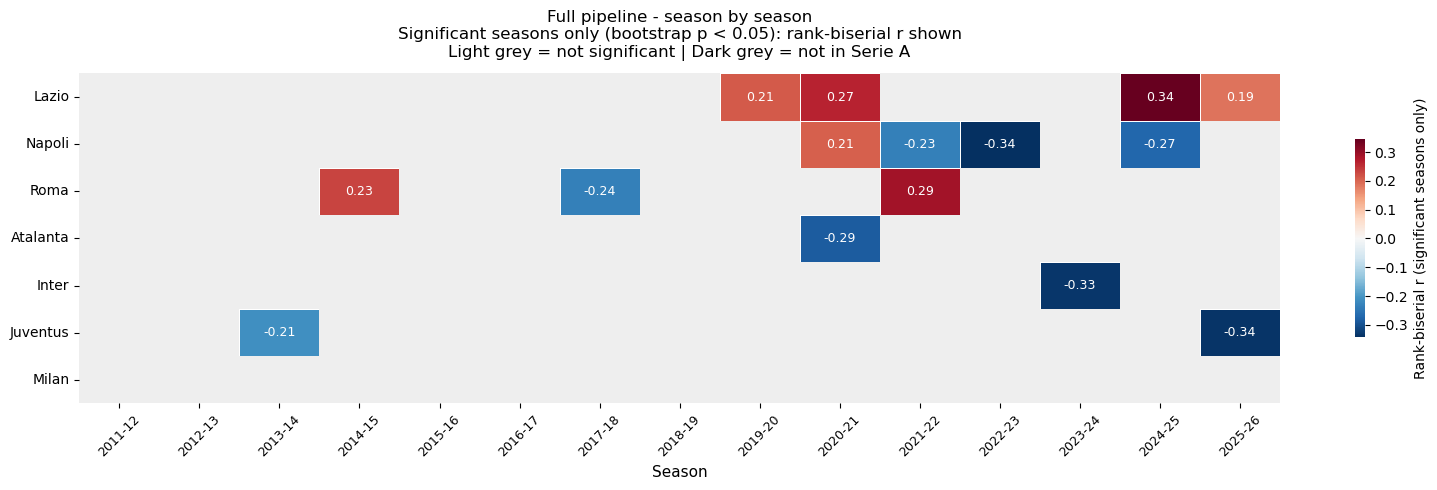

In [55]:
pivot_pboot = make_pivot('p_boot', season_results_df, candidates)
pivot_rrb   = make_pivot('r_rb',   season_results_df, candidates)
pivot_sig   = pivot_pboot < 0.05

# columns already renamed by make_pivot

# Show r_rb only where significant, mask elsewhere
pivot_rrb_masked = pivot_rrb.where(pivot_sig)

fig, ax = plt.subplots(figsize=(16, 5))

vmax_r = pivot_rrb.abs().max().max()
sns.heatmap(
    pivot_rrb_masked,
    ax=ax,
    cmap='RdBu_r',
    center=0,
    vmin=-vmax_r,
    vmax=vmax_r,
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 9},
    cbar_kws={'label': 'Rank-biserial r (significant seasons only)', 'shrink': 0.6},
    mask=pivot_rrb_masked.isna()
)

# Light grey for non-significant, dark grey for absent
for i, team in enumerate(candidates):
    for j, season in enumerate(readable_seasons):
        if pd.isna(pivot_pboot.loc[team, season]):
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#aaaaaa', lw=0))
        elif not pivot_sig.loc[team, season]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=True, color='#eeeeee', lw=0))

ax.set_title(
    'Full pipeline - season by season\n'
    'Significant seasons only (bootstrap p < 0.05): rank-biserial r shown\n'
    'Light grey = not significant | Dark grey = not in Serie A',
    fontsize=12, pad=12
)
ax.set_xlabel('Season', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.show()

### Stage A - Reading the season-by-season tables

**Methodological note: why bootstrap and Mann-Whitney disagree**

The two methods are measuring different things, and understanding the gap between them is important before interpreting the results.

The bootstrap tests whether the team's *aggregate crude rate* (total cards / total fouls across the whole season) deviates from the null distribution of season-level rates. It is a test of a single summary statistic. The Mann-Whitney tests whether the full *per-match rate distribution* of the team differs from that of the rest of the league. It is more sensitive to systematic distributional shifts - a team that consistently sits slightly below or above the median per-match rate will be detected by Mann-Whitney even when no single season is extreme enough for the bootstrap to flag. This explains the large gaps for Inter (1 boot, 4 MW) and Atalanta (1 boot, 3 MW): the effect is real but modest in magnitude, and the distribution-level test picks it up where the aggregate test cannot.

Neither method is wrong. They answer complementary questions. The disagreement is itself informative: it tells us the effect tends to be distributed consistently across matches rather than concentrated in a handful of extreme games.

---

**Lazio - a tale of two eras**

Bootstrap and Mann-Whitney agree on the core signal: 2019-20 and 2020-21 are the most robustly significant seasons (both methods, both years). Beyond that the two methods partially diverge. Mann-Whitney additionally flags 2012-13, 2023-24; bootstrap flags 2024-25 and 2025-26.

The 2012-13 Mann-Whitney result is directionally opposite to the post-2019 signal: in 2012-13 Lazio had *fewer* cards per foul than average (blue in the heatmap), whereas from 2019-20 onwards they have *more*. This is a complete reversal. Possible explanations include a change in playing style, squad composition, or manager. Lazio were managed by Vladimir Petkovic in 2012-13 (before Pioli took over mid-season). From 2016 onwards Simone Inzaghi managed the club until 2021, and Maurizio Sarri arrived in 2021-22. The transition from the Inzaghi era to Sarri is a candidate explanation for the red signal intensifying, but the signal actually starts in 2019-20 while Inzaghi was still in charge. This pre-dates the managerial change and complicates a simple "it's the manager" narrative. Needs further investigation in notebook 05.

---

**Napoli - a recent and consistent phenomenon**

The signal for Napoli is entirely post-2020 and concentrated in the most recent five seasons. Before 2020-21 there is not a single significant season by either method. From 2020-21 onwards, Mann-Whitney flags five seasons and bootstrap flags four. This is among the clearest temporal patterns in the entire dataset.

Managerially: Rino Gattuso managed Napoli from December 2019 to May 2021. Luciano Spalletti arrived in summer 2021 and stayed until 2023 (leaving after winning the Scudetto). Rudi Garcia followed for part of 2023-24, then Francesco Calzona briefly, then Antonio Conte from summer 2024. The fact that the signal persists across multiple managers (Gattuso's final season, all of Spalletti, and continuing under Conte) suggests this may not be purely a manager effect - something changed structurally at the club around 2020 that has persisted. The direction is consistently blue (fewer cards per foul than average), which combined with Napoli's historically technical style of play is worth noting.

---

**Roma - scattered and method-consistent**

Roma is unusual in that bootstrap and Mann-Whitney agree perfectly on the same three seasons: 2014-15, 2017-18, and 2021-22. This is the only team where the two methods identify exactly the same set of significant years. However, the three seasons are spread across three different managerial eras (Garcia 2014-15, Di Francesco 2017-18, Mourinho 2021-22) with long non-significant gaps between them. There is no obvious era-clustering or trend. The pooled signal for Roma is moderate and the Mann-Whitney on the pooled data is not significant (p = 0.13), which is consistent with an effect that is real in some years but inconsistent enough to dilute when averaged across all 15. Roma is the hardest case to build a structural narrative around.

---

**Atalanta - Gasperini's peak years**

Mann-Whitney flags three consecutive seasons: 2018-19, 2019-20, 2020-21. Bootstrap only flags 2020-21. The three MW seasons correspond almost exactly to what is widely considered Atalanta's peak under Gian Piero Gasperini - the period when they reached the Champions League quarter-final (2019-20) and were playing their most intense, high-volume pressing football. All three seasons are blue: *fewer* cards per foul than the league average. This is counterintuitive for a team known for heavy fouling, but a plausible explanation is that Gasperini's system involved fouling early, frequently, and away from goal - situations referees are less likely to punish with a card. The effect disappears after 2020-21 as the squad aged and the style evolved. Atalanta's signal may be more of a tactical era effect than a club-level structural one.

---

**Inter - the Inzaghi question, complicated**

Mann-Whitney flags four consecutive seasons: 2020-21, 2021-22, 2022-23, 2023-24. Bootstrap only flags 2023-24. The consecutive MW run is the most striking pattern for Inter, but the manager attribution is ambiguous. Simone Inzaghi arrived at Inter in summer 2021, so the signal starts in 2020-21 under Antonio Conte - one season before Inzaghi. This is important: if the effect were purely a manager import (Inzaghi bringing a Lazio-like pattern to Inter), it should not appear in 2020-21. Either the effect pre-existed Inzaghi and he maintained it, or the 2020-21 Mann-Whitney result is a false positive (p = 0.011, which is significant but not extreme). The direction is consistently blue: Inter receives fewer cards per foul than the rest of the league. The signal disappears in 2024-25 after Inzaghi left for the Portuguese national team and Simone Inzaghi was replaced by Cristian Chivu then Inzaghi returned... actually worth checking exact coaching timeline for Inter 2024-25.

Note for notebook 05: this is the central test case for the manager hypothesis. If Inzaghi's departure in 2024 coincides with the signal disappearing, the manager explanation is strengthened. If the signal persisted beyond his tenure, the club-level explanation is stronger.

---

**Juventus - two isolated windows**

Bootstrap: 2013-14 and 2025-26. Mann-Whitney adds 2014-15. The 2013-14 and 2014-15 seasons correspond to the final season of Antonio Conte and the first season of Massimo Allegri respectively. Juventus were dominant domestically in this period and playing a pragmatic, defensive style. The 2025-26 signal is under Thiago Motta, a very different stylistic profile. The gap of approximately 10 seasons between the two windows makes a single structural explanation unlikely. More plausible: two separate tactical eras that independently happened to produce a lower-than-average card rate for different reasons. The pooled result is significant (p_boot = 0.003) despite only 2-3 significant seasons - another demonstration of the power advantage of pooling.

---

**Milan - the benchmark null**

Zero significant seasons across 15 years by both methods. Every p-value is well above 0.05, with most above 0.3. This is the cleanest possible null result and serves as a calibration anchor for the entire analysis: the methodology does not systematically find effects where none exist. For a club of Milan's historical stature and public scrutiny, the complete absence of a disciplinary pattern is itself a substantive finding worth communicating to readers.

---

**Summary before Stage B**

Season by season, the picture is fragmented and easy to dismiss. Most teams show scattered significant seasons that could plausibly be chance. Only Napoli shows a genuinely clean consecutive pattern from a single era. The other signals are real but modest - exactly the regime where season-level tests lack power and pooling becomes essential. Stage B will show what happens when we give the test the full 15 seasons of data to work with.

### Stage B - Pooled across all seasons

We now aggregate all 15 seasons into a single test for each team. The question shifts from *"was this team an outlier in season X?"* to *"across the entire 15-season window, does this team's yellow card rate per foul consistently differ from the rest of the league?"*

With roughly 7,000 fouls per team in the pooled dataset - compared to roughly 500 per season - the test has 14 times more power to detect a modest but real effect.

## Section 5 - Deep dive: the full pipeline on pooled data

We now apply the full methodology from notebook 03 to each of the seven candidate teams, pooling all available seasons together.

**Why pool?** Running the test season by season gives us the temporal picture we already have in Section 4. Pooling all seasons into a single test asks a different and stronger question: *across the entire 15-season window as a whole, does this team's yellow card rate per foul differ from the rest of the league?* More data means more statistical power and a more reliable estimate of the underlying effect size.

**What we run for each team:**
1. Z-test and exact binomial on the pooled counts
2. Bootstrap test - resample match-level observations from the non-team pool
3. Mann-Whitney U test on per-match rates, with rank-biserial correlation as effect size

The seven candidates, in order of their season-level signal: **Lazio** (6 seasons), **Napoli** (4), **Roma** (4), **Atalanta** (3), **Inter** (2), **Juventus** (2), **Milan** (0).

In [56]:
def run_full_pipeline(team_name, df, n_bootstrap=10_000, seed=42):
    team_df = df[df['team'] == team_name].copy()
    rest_df = df[df['team'] != team_name].copy()

    n     = int(team_df['fouls_committed'].sum())
    k     = int(team_df['yellow_cards'].sum())
    p_hat = k / n
    p0    = rest_df['yellow_cards'].sum() / rest_df['fouls_committed'].sum()
    m     = len(team_df)

    # Z-test and exact binomial
    se      = np.sqrt(p0 * (1 - p0) / n)
    z       = (p_hat - p0) / se
    p_z     = 2 * stats.norm.cdf(-abs(z))
    p_binom = stats.binomtest(k, n, p0, alternative='two-sided').pvalue

    # Bootstrap
    rng = np.random.default_rng(seed)
    null_rates = np.array([
        rest_df.sample(n=m, replace=True, random_state=int(rng.integers(1e9)))
               ['yellow_cards'].sum() /
        rest_df.sample(n=m, replace=True, random_state=int(rng.integers(1e9)))
               ['fouls_committed'].sum()
        for _ in range(n_bootstrap)
    ])
    null_mean = null_rates.mean()
    p_boot    = (np.abs(null_rates - null_mean) >= abs(p_hat - null_mean)).mean()

    # Mann-Whitney
    team_rates = team_df['yellow_cards'] / team_df['fouls_committed']
    rest_rates = rest_df['yellow_cards'] / rest_df['fouls_committed']
    team_rates = team_rates.replace([np.inf, -np.inf], np.nan).dropna()
    rest_rates = rest_rates.replace([np.inf, -np.inf], np.nan).dropna()
    u_stat, p_mw = stats.mannwhitneyu(team_rates, rest_rates, alternative='two-sided')
    n1, n2 = len(team_rates), len(rest_rates)
    r_rb = (2 * u_stat) / (n1 * n2) - 1

    return dict(
        team=team_name, n=n, k=k, m=m,
        p_hat=p_hat, p0=p0,
        z=z, p_z=p_z, p_binom=p_binom,
        p_boot=p_boot, p_mw=p_mw, r_rb=r_rb,
        null_rates=null_rates
    )

In [57]:
_path_pooled = '../data/processed/notebook04/pooled_results.pkl'
if os.path.exists(_path_pooled):
    with open(_path_pooled, 'rb') as f:
        pipeline_results = pickle.load(f)
    print("Loaded pooled results from cache. Skip next cell.")
else:
    print("No cache found - run the pipeline cell below.")

Loaded pooled results from cache. Skip next cell.


In [ ]:
candidates = ['Lazio', 'Napoli', 'Roma', 'Atalanta', 'Inter', 'Juventus', 'Milan']

pipeline_results = {}
for team in candidates:
    pipeline_results[team] = run_full_pipeline(team, sa)
    print(f"{team}: done")

print("\nAll pipelines complete.")

In [ ]:
with open('../data/processed/notebook04/pooled_results.pkl', 'wb') as f:
    pickle.dump(pipeline_results, f)
print("Pooled results saved.")

In [58]:
summary = pd.DataFrame([
    {
        'Team':        r['team'],
        'n (fouls)':   r['n'],
        'k (cards)':   r['k'],
        'p_hat (k/n)': round(r['p_hat'], 4),
        'p0 (rest)':   round(r['p0'], 4),
        'diff':        round(r['p_hat'] - r['p0'], 4),
        'p (z-test)':  round(r['p_z'], 4),
        'p (binom)':   round(r['p_binom'], 4),
        'p (boot)':    round(r['p_boot'], 4),
        'p (MW)':      round(r['p_mw'], 4),
        'r_rb':        round(r['r_rb'], 3),
    }
    for r in pipeline_results.values()
])
summary

,Team,n (fouls),k (cards),p_hat (k/n),p0 (rest),diff,p (z-test),p (binom),p (boot),p (MW),r_rb
0,Lazio,7568,1323,0.1748,0.1626,0.0122,0.0039,0.0044,0.0087,0.0047,0.071
1,Napoli,6366,1002,0.1574,0.1634,-0.0060,0.1931,0.1977,0.1849,0.0610,-0.047
2,Roma,7157,1238,0.1730,0.1627,0.0103,0.0186,0.0194,0.0268,0.1295,0.038
3,Atalanta,7839,1198,0.1528,0.1637,-0.0109,0.0090,0.0091,0.0214,0.0025,-0.076
4,Inter,7158,1069,0.1493,0.1639,-0.0145,0.0009,0.0008,0.0018,0.0001,-0.099
5,Juventus,7246,1088,0.1502,0.1638,-0.0137,0.0017,0.0016,0.0031,0.0005,-0.087
6,Milan,7342,1209,0.1647,0.1631,0.0016,0.7172,0.7164,0.7382,0.8204,0.006


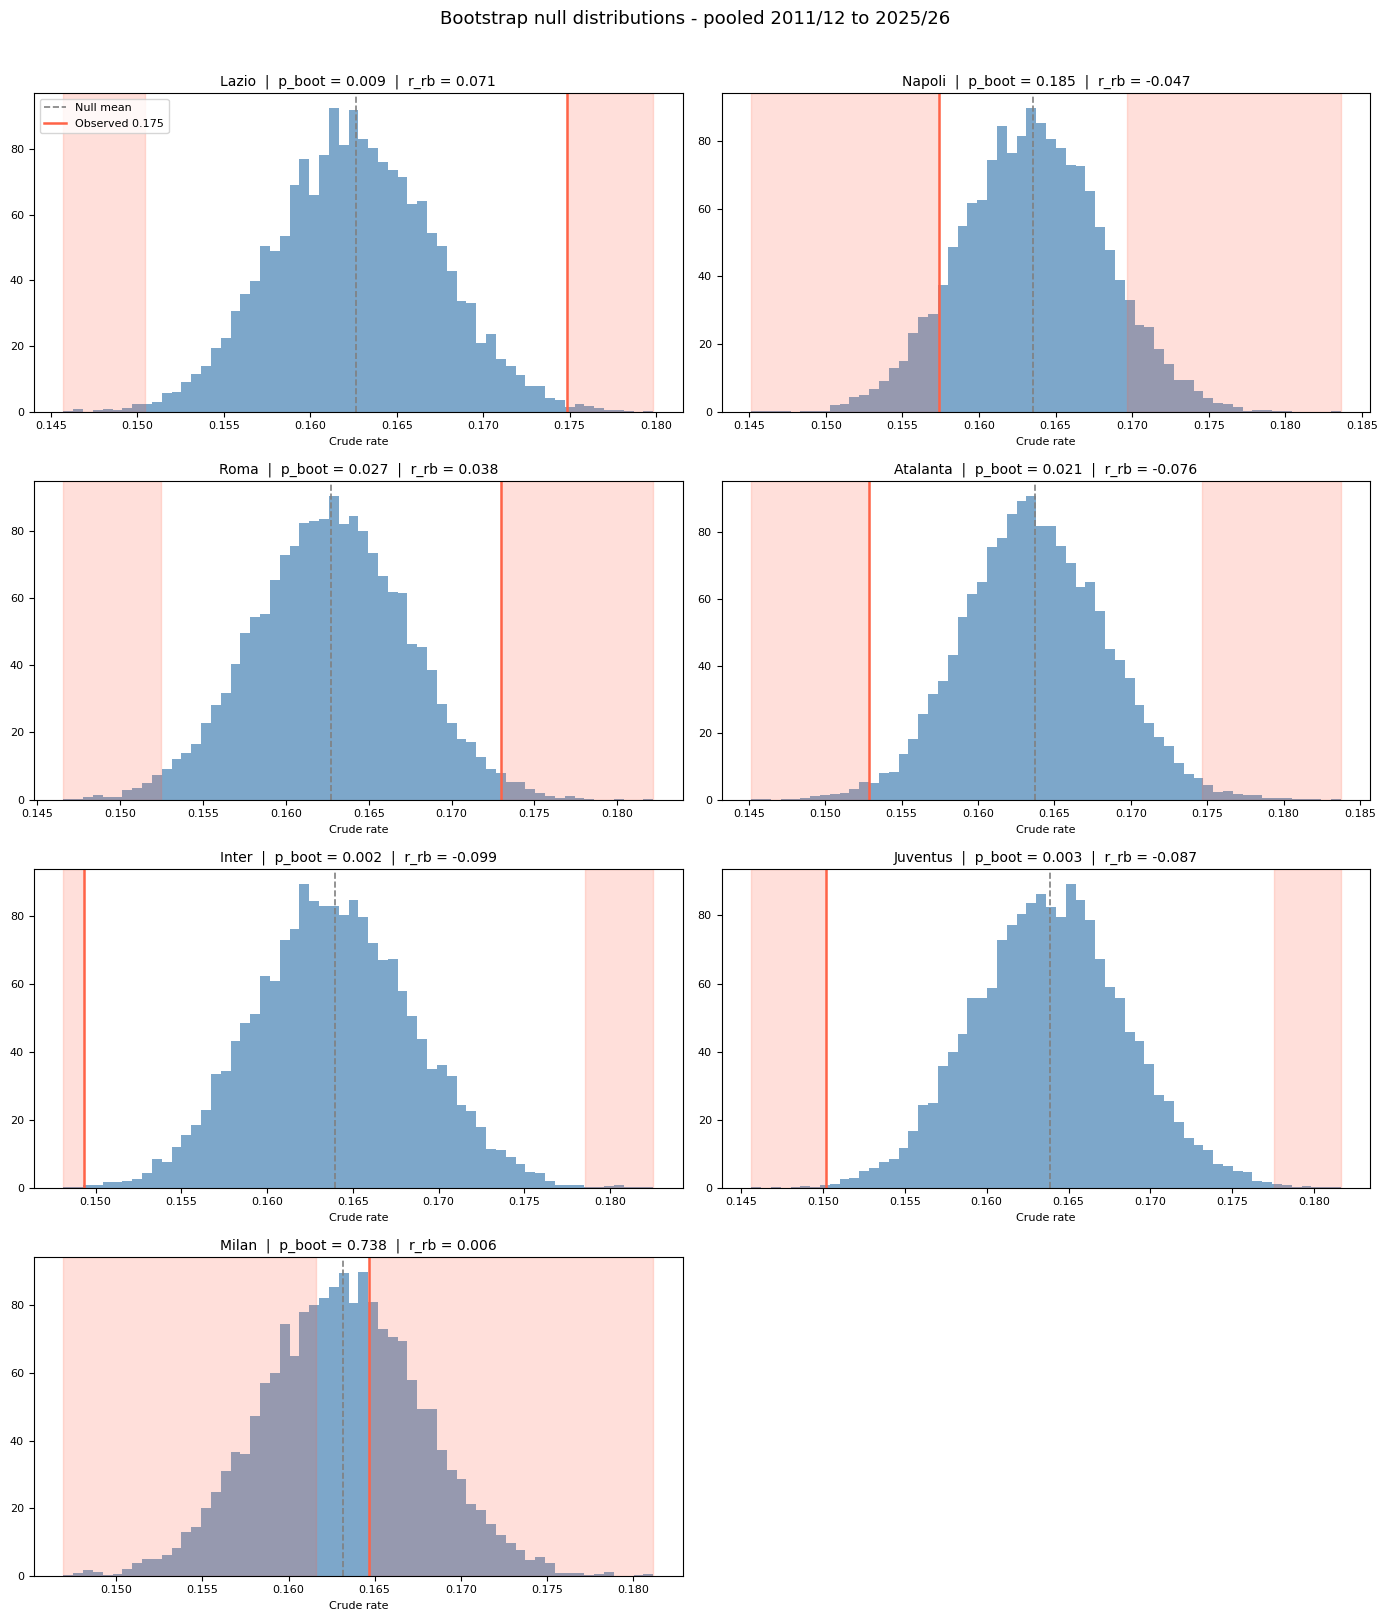

In [59]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for ax, team in zip(axes, candidates):
    r = pipeline_results[team]
    null = r['null_rates']
    p_hat = r['p_hat']
    null_mean = null.mean()
    distance = abs(p_hat - null_mean)

    ax.hist(null, bins=60, color='steelblue', alpha=0.7, density=True)
    ax.axvline(null_mean, color='grey', linestyle='--', linewidth=1.2, label='Null mean')
    ax.axvline(p_hat, color='tomato', linewidth=1.8, label=f'Observed {p_hat:.3f}')

    # Shade both tails
    tail_lo = null_mean - distance
    tail_hi = null_mean + distance
    ax.axvspan(null.min(), tail_lo, alpha=0.2, color='tomato')
    ax.axvspan(tail_hi, null.max(), alpha=0.2, color='tomato')

    ax.set_title(f'{team}  |  p_boot = {r["p_boot"]:.3f}  |  r_rb = {r["r_rb"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Crude rate', fontsize=8)
    ax.tick_params(labelsize=8)
    if ax == axes[0]:
        ax.legend(fontsize=8)

# Hide the last (empty) axis if 7 teams and 8 subplots
axes[-1].set_visible(False)

plt.suptitle('Bootstrap null distributions - pooled 2011/12 to 2025/26', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Stage B - Reading the pooled results

Full results table: $\hat{p}$ = team crude rate, $p_0$ = rest-of-league crude rate, both computed over the full 15-season pool.

| Team | n (fouls) | k (cards) | $\hat{p}$ | $p_0$ | diff | p (z) | p (binom) | p (boot) | p (MW) | $r_{rb}$ |
|------|-----------|-----------|-----------|-------|------|-------|-----------|----------|--------|----------|
| Lazio | 7568 | 1323 | 0.1748 | 0.1626 | +0.0122 | 0.004 | 0.004 | 0.009 | 0.005 | +0.071 |
| Napoli | 6366 | 1002 | 0.1574 | 0.1634 | -0.0060 | 0.193 | 0.198 | 0.185 | 0.061 | -0.047 |
| Roma | 7157 | 1238 | 0.1730 | 0.1627 | +0.0103 | 0.019 | 0.019 | 0.027 | 0.130 | +0.038 |
| Atalanta | 7839 | 1198 | 0.1528 | 0.1637 | -0.0109 | 0.009 | 0.009 | 0.021 | 0.003 | -0.076 |
| Inter | 7158 | 1069 | 0.1493 | 0.1639 | -0.0145 | 0.001 | 0.001 | 0.002 | 0.000 | -0.099 |
| Juventus | 7246 | 1088 | 0.1502 | 0.1638 | -0.0137 | 0.002 | 0.002 | 0.003 | 0.001 | -0.087 |
| Milan | 7342 | 1209 | 0.1647 | 0.1631 | +0.0016 | 0.717 | 0.716 | 0.738 | 0.820 | +0.006 |

---

**The power of pooling: Inter and Juventus**

This is the most striking methodological finding of the entire analysis. In Stage A, Inter and Juventus were each flagged as significant by the bootstrap in only 1 and 2 seasons respectively. From the season-by-season view alone, one could reasonably dismiss both as marginally above the noise threshold.

The pooled test tells a very different story. Inter: p_boot = 0.002, p_MW < 0.001, $r_{rb}$ = -0.099. Juventus: p_boot = 0.003, p_MW = 0.001, $r_{rb}$ = -0.087. Both are among the most significant results in the entire table, more significant than Lazio on the Mann-Whitney metric. The effect size ($r_{rb}$ around -0.09) is small but consistent: across roughly 7,000 fouls each, both clubs receive measurably fewer yellow cards per foul than the rest of Serie A.

The explanation is statistical power. With approximately 500 fouls per team per season, a crude rate difference of -0.014 (the Inter gap) produces a z-score of roughly 1.4 - not significant. Pooling 15 seasons multiplies the fouls by 15 and the z-score scales as $\sqrt{15} \approx 3.9$ times larger, easily crossing any standard threshold. The effect was always present in the data; individual seasons simply did not have enough observations to detect it reliably. This is a textbook demonstration of why longitudinal pooling matters.

Both clubs receive *fewer* cards per foul than average (blue direction). Whether this reflects playing style, squad experience (senior players knowing how to foul without triggering a card), or some other structural factor is a question for notebook 05. The Inter-Juventus parallel is itself worth noting: two historically dominant clubs, both in the same direction, both with effects that are individually invisible but collectively unmistakable.

---

**Napoli: the pooling paradox**

Napoli had 4-5 significant seasons in Stage A - one of the strongest season-level signals in the dataset. Yet the pooled test returns p_boot = 0.185 and p_MW = 0.061: not significant by any conventional threshold.

This is not a contradiction. It is a consequence of directional inconsistency. When seasons pointing in opposite directions are pooled together, the effects partially cancel. Napoli's significant seasons were mostly blue (fewer cards per foul) but the non-significant seasons scatter around the mean in both directions, and the net long-run crude rate difference is only -0.006 - smaller in absolute terms than any other team in the table except Milan.

The methodological lesson: a cluster of season-level significant results does not guarantee a significant pooled result. Napoli is structurally different from Inter and Juventus: their effect is real in certain seasons (particularly the post-2020 era) but reverses or fades in others, leaving no consistent long-run signal. This strengthens the hypothesis that Napoli's effect is era-specific rather than institutional - tied to a particular squad configuration or manager rather than something persistent about the club. The post-2020 window (5 consecutive MW-significant seasons) remains a genuine finding worth investigating in isolation in notebook 05, even if the 15-season average is null.

---

**Roma: a rate effect without a distribution effect**

Roma is significant by bootstrap (p = 0.027) and z-test (p = 0.019) but not by Mann-Whitney (p = 0.130). The crude rate difference is +0.010 (more cards per foul than average) with $r_{rb}$ = +0.038, the smallest effect size among the teams that do show a signal.

The divergence between parametric and non-parametric tests is informative. The bootstrap and z-test both work on the aggregate crude rate. Mann-Whitney compares the full distribution of per-match rates. The fact that the aggregate test detects a difference while the distributional test does not suggests Roma's elevated rate is driven by a subset of seasons or matches with unusually high rates - enough to pull the aggregate up but not enough to shift the median of the per-match distribution consistently. Combined with Stage A (three scattered seasons across completely different managerial eras), Roma is the weakest and least interpretable finding in this analysis. A moderate note of caution is warranted before carrying this result forward.

---

**Atalanta: the counterintuitive confirmed at scale**

Atalanta is significant by all four methods (p_boot = 0.021, p_MW = 0.003, $r_{rb}$ = -0.076). They receive fewer cards per foul than the league average across 15 seasons - despite having the largest n in the table (7,839 fouls), confirming they are consistently among the highest-fouling teams in Serie A.

High foul volume combined with a low card rate makes intuitive sense once you consider *where and when* fouls occur in Gasperini's system. High-press, man-marking tactics generate fouls in the middle third and in non-threatening positions, where referees are less likely to reach for a card. A team that fouls rarely but in dangerous positions near goal will accumulate more cards per foul by comparison. The crude rate therefore conflates foul frequency with foul dangerousness - Atalanta may simply be effective at fouling in the tactically "right" places from a disciplinary standpoint.

This has direct implications for notebook 05. If foul location data can be sourced, Atalanta is the primary test case for whether controlling for foul position eliminates the disciplinary anomaly entirely. Note also that the Stage A signal was concentrated in 2018-2021 (Gasperini's peak years) and faded afterwards, suggesting a tactical era effect rather than a permanent institutional one.

---

**Lazio: confirmed persistent outlier, red direction**

Lazio is significant across all four methods (p_boot = 0.009, p_MW = 0.005, $r_{rb}$ = +0.071) - the only team with a consistently positive effect in the pooled analysis. They receive more cards per foul than the rest of Serie A.

The effect size ($r_{rb}$ = +0.071) is modest but the pooled signal is robust. The Stage A analysis showed the signal is concentrated post-2019 with a possible directional reversal from the 2012-13 result. The pooled test absorbs both eras and returns a positive net effect, confirming the post-2019 red signal dominates. Importantly, the post-2019 signal pre-dates the arrival of Maurizio Sarri (summer 2021) and begins during Simone Inzaghi's final seasons in charge. This complicates a simple "new manager, new style" explanation and suggests the shift may have a different origin - squad turnover, referee perception built up over years, or something else. Lazio is the primary candidate for the manager-vs-institution investigation in notebook 05.

---

**Milan: the benchmark null, confirmed at scale**

$r_{rb}$ = +0.006, p_boot = 0.738, p_MW = 0.820. With 7,342 fouls in the pool, a crude rate difference of only +0.0016. This is statistically indistinguishable from zero by every measure. Milan is not an outlier in any direction across any time window. Zero significant seasons in Stage A, zero signal in Stage B.

This is the result that validates the methodology. A test that finds effects everywhere proves nothing; a test that clearly separates Milan (null) from Inter and Lazio (significant, opposite directions) is telling us something real. Milan serves as both a calibration anchor and a substantive finding: one of the most historically scrutinised clubs in Italian football shows no systematic disciplinary anomaly across 15 seasons.

---

**Overall picture and open questions for notebook 05**

Five of seven teams show a statistically detectable effect in at least one test. The direction clusters into two groups: Lazio and Roma receive *more* cards per foul than average; Atalanta, Inter, and Juventus receive *fewer*. Napoli has a real era-specific effect that averages out over 15 seasons. Milan is a clean null.

The two most important methodological lessons from this section:
1. Season-by-season analysis can miss real long-run effects (Inter, Juventus)
2. Season-by-season significance does not guarantee a long-run effect (Napoli)

Both lessons argue for always running both stages when the research question is about structural, multi-year patterns rather than single-season anomalies.

Open questions carried forward to notebook 05:
- Does the disciplinary effect follow the manager or the institution? (Lazio 2019,   Inter 2020-21 under Conte pre-Inzaghi, Juventus two isolated windows)
- Is Atalanta's low rate explained by foul location and dangerousness of fouls committed?
- Why does Roma's effect appear in only three scattered seasons with perfect method agreement?
- What does the specular analysis (cards drawn per foul received) reveal?
- Does controlling for home/away venue, opponent strength, or match stakes change   any of these results?
- Napoli post-2020: is this a Spalletti effect, a squad effect, or something else?